# Maximum likelihood estimation

Fitting a **family** of distributions to data: given a sample and a family, find the
parameters under which that sample is most probable.

$$\hat\theta = \arg\max_\theta\; \ell(\theta), \qquad
  \ell(\theta) = \sum_i \log f(x_i; \theta)$$

Estimation lives on the **family**, not on a distribution — a distribution already has
its parameters pinned, so there is nothing in it left to estimate. The entry point is
`family.fit(sample)`, which returns an `MLEResult`.

Two routes hide behind that one call:

| route | when | families here |
|---|---|---|
| **closed form** | the family declares an exact formula | `Normal`, `Exponential`, `ContinuousUniform` |
| **numerical** | otherwise | `Gamma` — L-BFGS-B with the analytical gradient from `score` |

Every figure below answers one question, stated just above it.

## 0. Setup

Two helpers do the repetitive work: `summarize` prints a result as a labelled block, so
no number appears without saying what it is, and `loglik_1d` / `loglik_2d` evaluate the
log-likelihood over a grid of parameter values — that is what all the surface plots are
made of.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.estimation import (
    OUT_OF_SUPPORT_PENALTY,
    log_likelihood,
    make_objective,
    resolve_bounds,
    starting_point,
    support_depends_on_params,
)
from pysatl_core.families.configuration import configure_families_register
from pysatl_core.types import FamilyName

registry = configure_families_register()
Normal = registry.get(FamilyName.NORMAL)
Uniform = registry.get(FamilyName.CONTINUOUS_UNIFORM)
Exponential = registry.get(FamilyName.EXPONENTIAL)
Gamma = registry.get(FamilyName.GAMMA)

rng = np.random.default_rng(20250901)

plt.rcParams.update({
    "figure.figsize": (9.5, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

DATA, FIT, ALT, BAD, MUTED = "#4C72B0", "#C44E52", "#55A868", "#D1495B", "#9A9A9A"
CMAP = "viridis"    # brighter = higher log-likelihood, on every surface plot below

In [2]:
def summarize(result, title=None):
    """Print an MLEResult as a labelled block: no bare numbers."""
    if title:
        print(title)
        print("-" * len(title))
    for name, value in result.params.parameters.items():
        print(f"  {name:<16} {value:>14.6f}")
    route = result.method + (f" via {result.optimizer}" if result.optimizer else "")
    print(f"  {'route':<16} {route:>14}")
    print(f"  {'converged':<16} {str(result.success):>14}")
    print(f"  {'log-likelihood':<16} {result.log_likelihood:>14.4f}   (higher = better fit)")
    print(f"  {'free parameters':<16} {result.n_params:>14d}   (estimated, not fixed)")
    print(f"  {'observations':<16} {result.n_observations:>14d}")
    print(f"  {'AIC':<16} {result.aic:>14.2f}   (lower = better, penalises parameters)")
    print(f"  {'BIC':<16} {result.bic:>14.2f}   (lower = better, penalises harder)")
    if result.n_iterations is not None:
        print(f"  {'optimizer work':<16} {result.n_iterations:>14d}   iterations, "
              f"{result.n_function_evaluations} objective evaluations")
    print(f"  message          {result.message}")


def loglik_1d(family, sample, name, values, **others):
    """log-likelihood along one parameter, the others held fixed."""
    return np.array([
        log_likelihood(family, family.base(**{name: float(v), **others}), sample)
        for v in values
    ])


def loglik_2d(family, sample, name_x, xs, name_y, ys):
    """log-likelihood over a grid of two parameters; rows follow ys, columns xs."""
    surface = np.empty((ys.size, xs.size))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            surface[i, j] = log_likelihood(
                family, family.base(**{name_x: float(x), name_y: float(y)}), sample
            )
    return surface

## 1. A first fit

`Normal` declares a closed-form MLE, so `fit` returns the exact answer and no optimizer
runs at all.

In [3]:
sample = rng.normal(loc=2.0, scale=1.5, size=1000)
result = Normal.fit(sample)

summarize(result, "Normal.fit(sample)  —  1000 draws from N(2, 1.5)")

Normal.fit(sample)  —  1000 draws from N(2, 1.5)
------------------------------------------------
  mu                     1.924508
  sigma                  1.475941
  route               closed_form
  converged                  True
  log-likelihood       -1808.2342   (higher = better fit)
  free parameters               2   (estimated, not fixed)
  observations               1000
  AIC                     3620.47   (lower = better, penalises parameters)
  BIC                     3630.28   (lower = better, penalises harder)
  message          closed-form maximum likelihood solution


**Does the fitted distribution actually describe the data?** The left panel overlays the
estimated density on the histogram; the right compares the fitted CDF with the empirical
one. If the fit is good, the curves sit on the data.

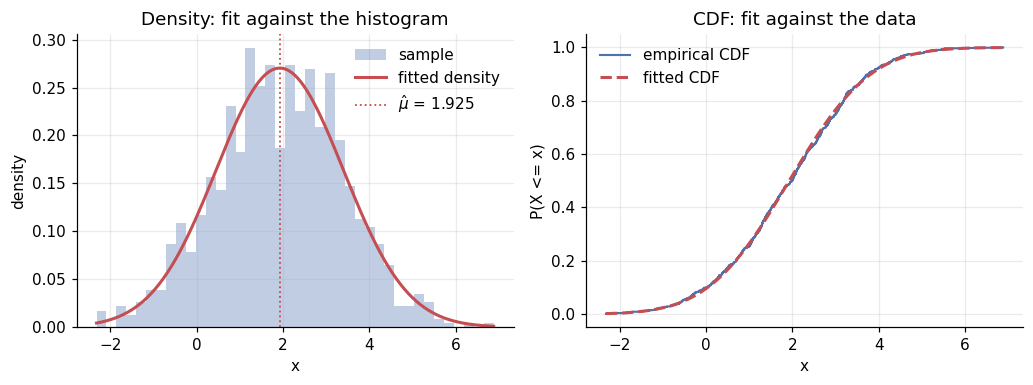

In [4]:
distribution = result.distribution      # built on access, not stored in the result
grid = np.linspace(sample.min(), sample.max(), 400)

fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(9.5, 3.6))

ax_pdf.hist(sample, bins=40, density=True, color=DATA, alpha=0.35, label="sample")
ax_pdf.plot(grid, distribution.calculate_characteristic("pdf", grid),
            color=FIT, lw=2, label="fitted density")
ax_pdf.axvline(result.params.mu, color=FIT, ls=":", lw=1.2,
               label=rf"$\hat\mu$ = {result.params.mu:.3f}")
ax_pdf.set(xlabel="x", ylabel="density", title="Density: fit against the histogram")
ax_pdf.legend()

ordered = np.sort(sample)
ax_cdf.step(ordered, np.arange(1, sample.size + 1) / sample.size,
            color=DATA, lw=1.4, where="post", label="empirical CDF")
ax_cdf.plot(grid, distribution.calculate_characteristic("cdf", grid),
            color=FIT, lw=2, ls="--", label="fitted CDF")
ax_cdf.set(xlabel="x", ylabel="P(X <= x)", title="CDF: fit against the data")
ax_cdf.legend()

fig.tight_layout()
plt.show()

### The divisor is `n`, not `n - 1`

The maximum likelihood estimate of the variance divides by `n`. The familiar `n - 1`
version answers a *different* question — unbiasedness — and is a genuinely different
number.

**Which one maximises the likelihood?** The curve below is $\ell$ as a function of
$\sigma$, with $\mu$ held at its estimate. Only one of the two candidates sits at the
peak.

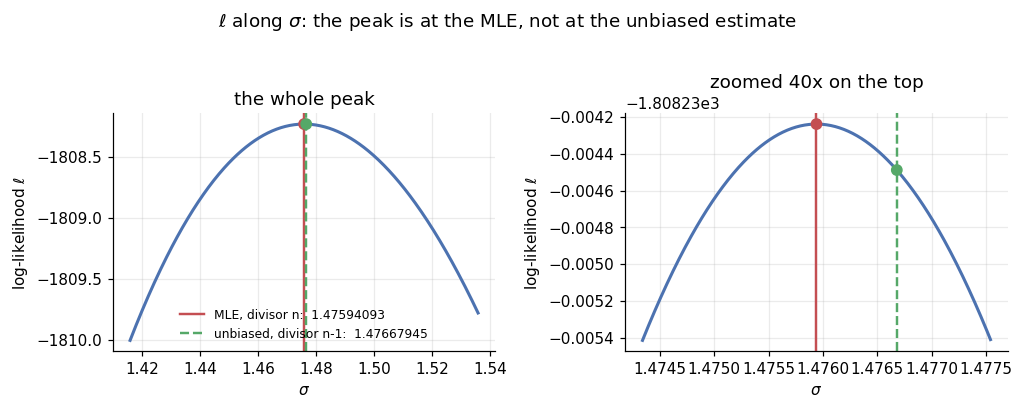

the two estimates differ by      7.39e-04
log-likelihood at the MLE        -1808.23423815
log-likelihood at the unbiased   -1808.23448832
difference (the MLE must win)    2.50e-04


In [5]:
mle_sigma = result.params.sigma
unbiased_sigma = sample.std(ddof=1)
at = lambda s: log_likelihood(Normal, Normal.base(mu=result.params.mu, sigma=s), sample)

fig, (ax_wide, ax_zoom) = plt.subplots(1, 2, figsize=(9.5, 3.6))

for ax, half_width, title in ((ax_wide, 0.06, "the whole peak"),
                              (ax_zoom, 0.0016, "zoomed 40x on the top")):
    sigmas = np.linspace(mle_sigma - half_width, mle_sigma + half_width, 400)
    ax.plot(sigmas, loglik_1d(Normal, sample, "sigma", sigmas, mu=result.params.mu),
            color=DATA, lw=2)
    ax.axvline(mle_sigma, color=FIT, lw=1.6)
    ax.axvline(unbiased_sigma, color=ALT, ls="--", lw=1.6)
    ax.scatter([mle_sigma, unbiased_sigma], [at(mle_sigma), at(unbiased_sigma)],
               color=[FIT, ALT], zorder=5, s=45)
    ax.set(xlabel=r"$\sigma$", ylabel=r"log-likelihood $\ell$", title=title)

ax_wide.legend(handles=[
    plt.Line2D([], [], color=FIT, lw=1.6, label=f"MLE, divisor n:  {mle_sigma:.8f}"),
    plt.Line2D([], [], color=ALT, lw=1.6, ls="--",
               label=f"unbiased, divisor n-1:  {unbiased_sigma:.8f}"),
], loc="lower center", fontsize=8)
fig.suptitle(r"$\ell$ along $\sigma$: the peak is at the MLE, not at the unbiased estimate",
             y=1.02)
fig.tight_layout()
plt.show()

print(f"the two estimates differ by      {unbiased_sigma - mle_sigma:.2e}")
print(f"log-likelihood at the MLE        {at(mle_sigma):.8f}")
print(f"log-likelihood at the unbiased   {at(unbiased_sigma):.8f}")
print(f"difference (the MLE must win)    {at(mle_sigma) - at(unbiased_sigma):.2e}")

## 2. The result is an object, not a tuple

A bare tuple of parameters — the shape of the old `scipy.stats.rv_continuous.fit` API —
carries neither the attained likelihood nor a convergence flag, so a caller cannot tell a
converged fit from a silently failed one. `MLEResult` carries all of it, which is why
`summarize` above had something to print, and derives the information criteria for free.

| field | question it answers |
|---|---|
| `params` | what are the estimates? |
| `log_likelihood` | how well does this fit the data? |
| `success`, `message` | can I trust it? what happened? |
| `method`, `optimizer` | how was it obtained? |
| `n_params` | how many parameters were *estimated* (not fixed)? |
| `aic`, `bic` | how does it compare with a rival model? |
| `distribution` | give me the fitted distribution |

## 3. Fixing some parameters

Parameters are pinned with `view()` — deliberately the only mechanism (there is no
counterpart to SciPy's `floc=`/`fa=`). A view **is** a family, so `fit` works on it
unchanged, and `n_params` counts only what was actually estimated.

In [6]:
centred = rng.normal(loc=0.0, scale=3.0, size=800)   # pinning mu=0 is CORRECT here
offset = rng.normal(loc=1.2, scale=3.0, size=800)    # pinning mu=0 is WRONG here

free = Normal.fit(centred)
pinned = Normal.view(mu=0.0).fit(centred)

summarize(free, "Normal.fit(centred)  —  both parameters free")
print()
summarize(pinned, "Normal.view(mu=0).fit(centred)  —  mu pinned at 0")

Normal.fit(centred)  —  both parameters free
--------------------------------------------
  mu                    -0.012791
  sigma                  2.977418
  route               closed_form
  converged                  True
  log-likelihood       -2007.9960   (higher = better fit)
  free parameters               2   (estimated, not fixed)
  observations                800
  AIC                     4019.99   (lower = better, penalises parameters)
  BIC                     4029.36   (lower = better, penalises harder)
  message          closed-form maximum likelihood solution

Normal.view(mu=0).fit(centred)  —  mu pinned at 0
-------------------------------------------------
  sigma                  2.977445
  route               closed_form
  converged                  True
  log-likelihood       -2008.0034   (higher = better fit)
  free parameters               1   (estimated, not fixed)
  observations                800
  AIC                     4018.01   (lower = better, penalises p

**What does pinning do geometrically?** The contours below are the log-likelihood over
$(\mu, \sigma)$. The free fit finds the top of the hill; pinning $\mu = 0$ restricts the
search to a vertical line, and the constrained estimate is the highest point *on that line*.

The two panels show why `n_params` matters. On the **left** the sample really is centred, so
the line passes through the peak: pinning costs almost no likelihood and AIC rewards the
saved parameter. On the **right** the sample is centred at 1.2, so the line misses the peak;
the constrained fit has to absorb the offset by inflating $\sigma$, and AIC now prefers the
free model.

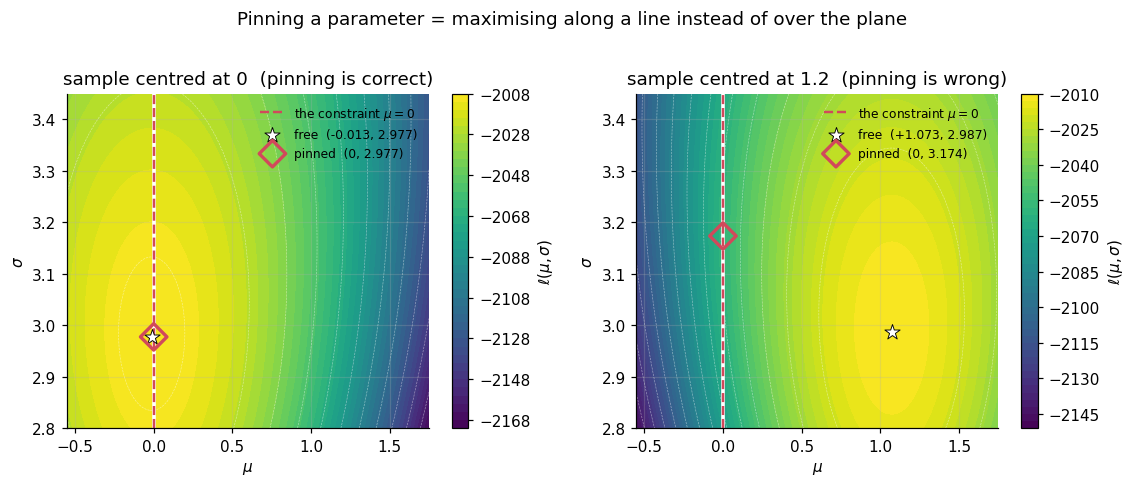

                                              free      pinned   preferred
sample centred at 0  (pinning is correct)     4019.99     4018.01      pinned   (AIC)
sample centred at 1.2  (pinning is wrong)     4025.00     4120.04        free   (AIC)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
rows = []

for ax, data, label in ((axes[0], centred, "sample centred at 0  (pinning is correct)"),
                        (axes[1], offset, "sample centred at 1.2  (pinning is wrong)")):
    free_fit = Normal.fit(data)
    pinned_fit = Normal.view(mu=0.0).fit(data)
    rows.append((label, free_fit, pinned_fit))

    mus = np.linspace(-0.55, 1.75, 110)
    sigmas = np.linspace(2.80, 3.45, 110)
    surface = loglik_2d(Normal, data, "mu", mus, "sigma", sigmas)

    filled = ax.contourf(mus, sigmas, surface, levels=45, cmap=CMAP)
    ax.contour(mus, sigmas, surface, levels=14, colors="white", linewidths=0.4, alpha=0.5)
    fig.colorbar(filled, ax=ax, label=r"$\ell(\mu, \sigma)$")

    ax.axvline(0.0, color="white", lw=2.4)
    ax.axvline(0.0, color=BAD, lw=1.6, ls="--", label=r"the constraint $\mu = 0$")
    ax.scatter([free_fit.params.mu], [free_fit.params.sigma], color="white", s=110,
               marker="*", zorder=5, edgecolor="black", linewidth=0.6,
               label=f"free  ({free_fit.params.mu:+.3f}, {free_fit.params.sigma:.3f})")
    ax.scatter([0.0], [pinned_fit.params.sigma], facecolor="none", s=150, marker="D",
               zorder=6, edgecolor=BAD, linewidth=2.2,
               label=f"pinned  (0, {pinned_fit.params.sigma:.3f})")
    ax.set(xlabel=r"$\mu$", ylabel=r"$\sigma$", title=label, ylim=(2.80, 3.45))
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Pinning a parameter = maximising along a line instead of over the plane",
             y=1.02)
fig.tight_layout()
plt.show()

print(f"{'':38}{'free':>12}{'pinned':>12}{'preferred':>12}")
for label, free_fit, pinned_fit in rows:
    winner = "pinned" if pinned_fit.aic < free_fit.aic else "free"
    print(f"{label:38}{free_fit.aic:>12.2f}{pinned_fit.aic:>12.2f}{winner:>12}   (AIC)")

## 4. The numerical path

`Gamma` declares no closed-form MLE — the estimate needs
$\log k - \psi(k) = \log\bar x - \overline{\log x}$ solved numerically — so `fit` runs the
optimizer: L-BFGS-B, started at the method-of-moments point, with the analytical gradient
assembled from the family's `score`.

In [8]:
gamma_sample = rng.gamma(shape=2.5, scale=1.7, size=2000)
gamma_result = Gamma.fit(gamma_sample)

summarize(gamma_result, "Gamma.fit(sample)  —  2000 draws from Gamma(k=2.5, theta=1.7)")

Gamma.fit(sample)  —  2000 draws from Gamma(k=2.5, theta=1.7)
-------------------------------------------------------------
  k                      2.470159
  theta                  1.684711
  route            numeric via L-BFGS-B
  converged                  True
  log-likelihood       -4487.1784   (higher = better fit)
  free parameters               2   (estimated, not fixed)
  observations               2000
  AIC                     8978.36   (lower = better, penalises parameters)
  BIC                     8989.56   (lower = better, penalises harder)
  optimizer work                5   iterations, 7 objective evaluations
  message          CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


**Where does the optimizer actually go?** Replaying the same search with a callback
records every iterate. Seven objective evaluations take it from the moment estimate to the
peak; the analytical gradient is what makes the path this short.

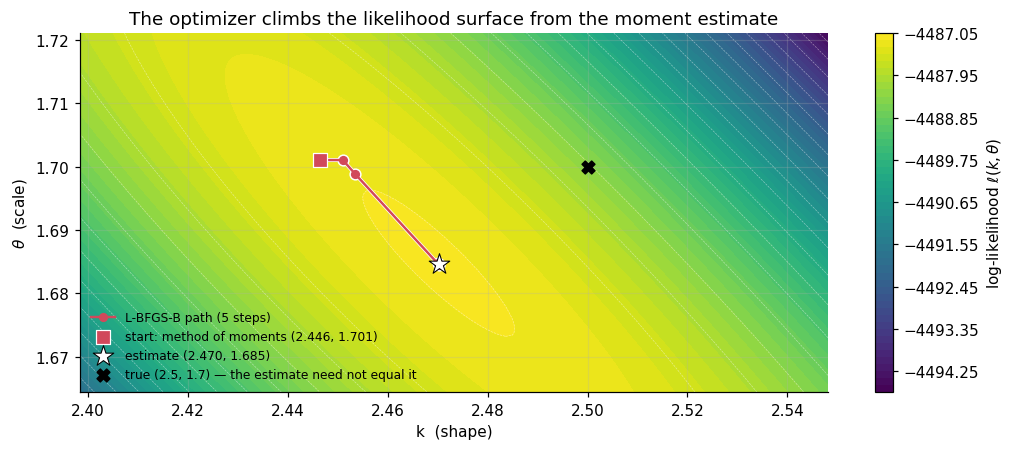

In [9]:
from scipy.optimize import minimize

objective, gradient = make_objective(Gamma, gamma_sample)
x0 = np.array([starting_point(Gamma, gamma_sample).parameters[n] for n in ("k", "theta")])

path = [x0.copy()]
minimize(objective, x0, jac=gradient, method="L-BFGS-B",
         bounds=resolve_bounds(Gamma), callback=lambda xk: path.append(xk.copy()))
path = np.array(path)

def window(values, pad_fraction=0.9, floor=0.02):
    # An axis range that holds `values` with room to breathe.
    low, high = float(np.min(values)), float(np.max(values))
    pad = max(pad_fraction * (high - low), floor)
    return np.linspace(low - pad, high + pad, 110)

ks = window(np.r_[path[:, 0], gamma_result.params.k, 2.5])
thetas = window(np.r_[path[:, 1], gamma_result.params.theta, 1.7])
surface = loglik_2d(Gamma, gamma_sample, "k", ks, "theta", thetas)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
filled = ax.contourf(ks, thetas, surface, levels=60, cmap=CMAP)
ax.contour(ks, thetas, surface, levels=18, colors="white", linewidths=0.4, alpha=0.5)
fig.colorbar(filled, ax=ax, label=r"log-likelihood $\ell(k, \theta)$")

ax.plot(path[:, 0], path[:, 1], "-o", color="white", lw=2.6, ms=7, zorder=5)
ax.plot(path[:, 0], path[:, 1], "-o", color=BAD, lw=1.6, ms=5, zorder=6,
        label=f"L-BFGS-B path ({len(path) - 1} steps)")
ax.scatter(path[0, 0], path[0, 1], color=BAD, s=95, marker="s", zorder=7,
           edgecolor="white", linewidth=0.8,
           label=f"start: method of moments ({path[0, 0]:.3f}, {path[0, 1]:.3f})")
ax.scatter([gamma_result.params.k], [gamma_result.params.theta], color="white", s=200,
           marker="*", zorder=7, edgecolor="black", linewidth=0.7,
           label=f"estimate ({gamma_result.params.k:.3f}, {gamma_result.params.theta:.3f})")
ax.scatter([2.5], [1.7], color="black", s=70, marker="X", zorder=7,
           label="true (2.5, 1.7) — the estimate need not equal it")
ax.set(xlabel="k  (shape)", ylabel=r"$\theta$  (scale)",
       title="The optimizer climbs the likelihood surface from the moment estimate")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
plt.show()

**Cross-check against SciPy**, which solves the same problem numerically. `floc=0` pins
SciPy's location parameter, which this family does not have — its support starts at 0 by
definition.

In [10]:
from scipy import stats

shape, loc, scale = stats.gamma.fit(gamma_sample, floc=0)
scipy_ll = float(np.sum(stats.gamma.logpdf(gamma_sample, shape, loc=0, scale=scale)))

print(f"{'':14}{'k':>14}{'theta':>14}{'log-likelihood':>20}")
print(f"{'pysatl-core':14}{gamma_result.params.k:>14.8f}"
      f"{gamma_result.params.theta:>14.8f}{gamma_result.log_likelihood:>20.10f}")
print(f"{'scipy':14}{shape:>14.8f}{scale:>14.8f}{scipy_ll:>20.10f}")
print()
print(f"agreement: parameters to {abs(gamma_result.params.k - shape):.1e}, "
      f"log-likelihood to {abs(gamma_result.log_likelihood - scipy_ll):.1e}")

                           k         theta      log-likelihood
pysatl-core       2.47015912    1.68471144    -4487.1783769642
scipy             2.47015927    1.68471135    -4487.1783769642

agreement: parameters to 1.5e-07, log-likelihood to 1.8e-12


## 5. Where a gradient method fails: the uniform family

For `ContinuousUniform` the maximum sits **on the boundary** of the admissible region, at
`min(x)` and `max(x)`. There is no stationary point to converge to — the score is the
constant $[\,1/(b-a),\; -1/(b-a)\,]$ and never vanishes — and every parameter step moves
the support, so the objective is discontinuous exactly where the answer is.

The closed-form solution is therefore not a convenience but the only reliable route.

In [11]:
uniform_sample = rng.uniform(2.0, 5.0, 500)
exact = Uniform.fit(uniform_sample)

summarize(exact, "ContinuousUniform.fit(sample)  —  500 draws from U(2, 5)")
print()
print(f"the estimates are exactly the sample extremes: "
      f"min={uniform_sample.min():.6f}, max={uniform_sample.max():.6f}")

ContinuousUniform.fit(sample)  —  500 draws from U(2, 5)
--------------------------------------------------------
  lower_bound            2.000349
  upper_bound            4.993817
  route               closed_form
  converged                  True
  log-likelihood        -548.2163   (higher = better fit)
  free parameters               2   (estimated, not fixed)
  observations                500
  AIC                     1100.43   (lower = better, penalises parameters)
  BIC                     1108.86   (lower = better, penalises harder)
  message          closed-form maximum likelihood solution

the estimates are exactly the sample extremes: min=2.000349, max=4.993817


Passing `optimizer=` forces the numerical path. Unlike SciPy — whose overridden `fit`
methods silently discard the argument — the request is honoured, but two warnings say what
is being given up, and the caveat is copied into `message` so it survives into logs.

In [12]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    numeric = Uniform.fit(uniform_sample, optimizer="L-BFGS-B")

for i, w in enumerate(caught, 1):
    print(f"warning {i}: {w.message}\n")

print(f"{'':12}{'lower_bound':>14}{'upper_bound':>14}{'log-likelihood':>18}")
print(f"{'closed form':12}{exact.params.lower_bound:>14.6f}"
      f"{exact.params.upper_bound:>14.6f}{exact.log_likelihood:>18.6f}")
print(f"{'numeric':12}{numeric.params.lower_bound:>14.6f}"
      f"{numeric.params.upper_bound:>14.6f}{numeric.log_likelihood:>18.6f}")
print()
print(f"the numeric interval is {(numeric.params.upper_bound - numeric.params.lower_bound) - (exact.params.upper_bound - exact.params.lower_bound):+.4f} wider "
      f"and loses {exact.log_likelihood - numeric.log_likelihood:.3f} of log-likelihood")

warning 1: family 'ContinuousUniform' has a closed-form MLE, but 'optimizer=L-BFGS-B' was passed, so the numerical path is used

warning 2: the numerical path is unreliable for a uniform family: the likelihood maximum sits on the boundary of the admissible region (at min(x) and max(x)) and the objective surface is discontinuous there, so a gradient method cannot reach it; prefer the closed-form solution by omitting 'optimizer'

warning 3: Family 'ContinuousUniform' declares no 'param_bounds', so the optimizer runs without bounds and may probe inadmissible parameters. The objective rejects those with 'inf', so the fit is still correct, only slower and less robust. Pass 'param_bounds={...}' to the family constructor to fix this.

               lower_bound   upper_bound    log-likelihood
closed form       2.000349      4.993817       -548.216298
numeric           1.994313      4.999854       -550.228867

the numeric interval is +0.0121 wider and loses 2.013 of log-likelihood


**Where exactly do the two answers differ?** Nowhere you can see at full scale — the gap is
about 0.006 in each endpoint. The bottom panels zoom in on the two edges, with the individual
observations drawn as ticks. The closed form lands **exactly** on the extreme observation;
the numerical search stops a little outside it and never gets closer.

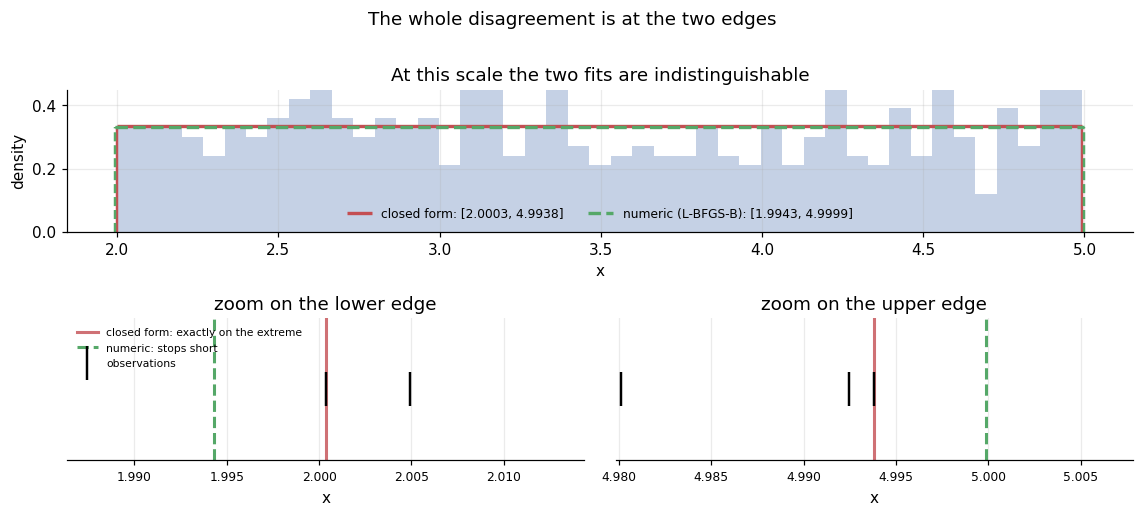

Any interval covering the data is admissible; the narrowest one wins, because
the uniform likelihood (b - a)^-n grows as the interval shrinks. The optimizer
stops early: narrowing further would drop an observation, and that costs a
penalty of 70,978 — far more than the 2.01 it would gain.


In [13]:
fig = plt.figure(figsize=(10.5, 4.6))
ax_full = fig.add_subplot(2, 1, 1)
ax_left = fig.add_subplot(2, 2, 3)
ax_right = fig.add_subplot(2, 2, 4)

ax_full.hist(uniform_sample, bins=45, density=True, color=DATA, alpha=0.32)
for res, colour, style, name in ((exact, FIT, "-", "closed form"),
                                 (numeric, ALT, "--", "numeric (L-BFGS-B)")):
    a, b = res.params.lower_bound, res.params.upper_bound
    ax_full.hlines(1.0 / (b - a), a, b, color=colour, lw=2.2, ls=style,
                   label=f"{name}: [{a:.4f}, {b:.4f}]")
    ax_full.vlines([a, b], 0, 1.0 / (b - a), color=colour, lw=1.6, ls=style)
ax_full.set(xlabel="x", ylabel="density", ylim=(0, 0.45),
            title="At this scale the two fits are indistinguishable")
ax_full.legend(loc="lower center", fontsize=8, ncol=2)

# The whole difference lives in the last few micrometres at each edge.
for ax, edge, side in ((ax_left, uniform_sample.min(), "lower"),
                       (ax_right, uniform_sample.max(), "upper")):
    span = 0.014
    nearby = uniform_sample[np.abs(uniform_sample - edge) < span]
    ax.axvline(getattr(exact.params, f"{side}_bound"), color=FIT, lw=2, alpha=0.8,
               label="closed form: exactly on the extreme")
    ax.axvline(getattr(numeric.params, f"{side}_bound"), color=ALT, ls="--", lw=2,
               label="numeric: stops short")
    ax.plot(nearby, np.zeros(nearby.size), "|", color="black", ms=22, mew=1.6,
            zorder=5, label="observations")
    ax.set(xlim=(edge - span, edge + span), yticks=[], xlabel="x",
           title=f"zoom on the {side} edge")
    ax.tick_params(axis="x", labelsize=8)
    ax.spines["left"].set_visible(False)   # else it reads as another observation

ax_left.legend(loc="upper left", fontsize=7, ncol=1)
fig.suptitle("The whole disagreement is at the two edges", y=1.01)
fig.tight_layout()
plt.show()

print("Any interval covering the data is admissible; the narrowest one wins, because")
print("the uniform likelihood (b - a)^-n grows as the interval shrinks. The optimizer")
print("stops early: narrowing further would drop an observation, and that costs a")
print(f"penalty of {OUT_OF_SUPPORT_PENALTY:,.0f} — far more than the {exact.log_likelihood - numeric.log_likelihood:.2f} it would gain.")

## 6. The objective function, and why the penalty is finite

The objective is $-\ell(\theta)$ plus a fixed charge for every observation the current
parameters cannot explain:

$$\text{objective} = -\!\!\sum_{i\ \text{explained}}\!\! \log f(x_i;\theta)
   \;+\; n_{\text{unexplained}} \cdot \text{PENALTY}$$

The charge is finite rather than infinite on purpose: `inf` is a plateau with no direction
to descend, whereas a per-violation charge encodes "explain more of the data", which a
search can act on.

**The three panels below are the same slice at three scales.** Moving `upper_bound` below
`max(x)` excludes observations one at a time, and each exclusion adds one step of the
penalty — the staircase in the middle panel. To the right of `max(x)` the objective is
smooth, and its minimum sits exactly on the boundary.

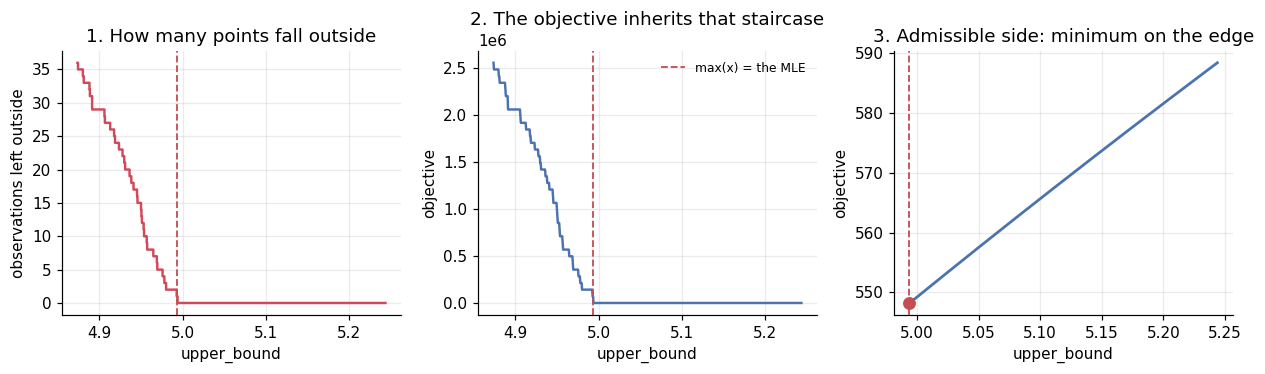

penalty per unexplained observation: 70,978.27  = log(largest float) x 100
one step of the staircase in panel 2 is exactly that height

A gradient method starting to the right of max(x) slides left until the wall,
and cannot cross it — which is the whole reason the closed form exists.


In [14]:
a_hat, b_hat = exact.params.lower_bound, exact.params.upper_bound
objective, _ = make_objective(Uniform, uniform_sample)

wide = np.linspace(b_hat - 0.12, b_hat + 0.25, 700)
values = np.array([objective(np.array([a_hat, b])) for b in wide])
violations = np.array([(uniform_sample > b).sum() for b in wide])

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))

axes[0].step(wide, violations, color=BAD, lw=1.6, where="post")
axes[0].axvline(b_hat, color=FIT, ls="--", lw=1.2)
axes[0].set(xlabel="upper_bound", ylabel="observations left outside",
            title="1. How many points fall outside")

axes[1].plot(wide, values, color=DATA, lw=1.6)
axes[1].axvline(b_hat, color=FIT, ls="--", lw=1.2, label="max(x) = the MLE")
axes[1].set(xlabel="upper_bound", ylabel="objective",
            title="2. The objective inherits that staircase")
axes[1].legend(loc="upper right", fontsize=8)

right = wide >= b_hat
axes[2].plot(wide[right], values[right], color=DATA, lw=1.8)
axes[2].axvline(b_hat, color=FIT, ls="--", lw=1.2)
axes[2].scatter([b_hat], [values[right][0]], color=FIT, s=55, zorder=5)
axes[2].set(xlabel="upper_bound", ylabel="objective",
            title="3. Admissible side: minimum on the edge")

fig.tight_layout()
plt.show()

print(f"penalty per unexplained observation: {OUT_OF_SUPPORT_PENALTY:,.2f}  "
      f"= log(largest float) x 100")
print(f"one step of the staircase in panel 2 is exactly that height")
print()
print("A gradient method starting to the right of max(x) slides left until the wall,")
print("and cannot cross it — which is the whole reason the closed form exists.")

## 7. The gradient is the family's own score

`make_objective` returns the objective together with its analytical gradient, obtained by
summing `family.score` over the observations the current parameters explain. That gradient
is what L-BFGS-B follows in section 4.

**Two checks.** Numerically, against a central difference. Visually, as a field of arrows:
every arrow points downhill on the objective, and they all converge on the estimate.

In [15]:
normal_objective, normal_gradient = make_objective(Normal, sample)

probe = np.array([1.7, 1.3])
analytic = normal_gradient(probe)
eps = 1e-6
numeric_gradient = np.array([
    (normal_objective(probe + step) - normal_objective(probe - step)) / (2 * eps)
    for step in (np.array([eps, 0.0]), np.array([0.0, eps]))
])

print(f"at (mu, sigma) = ({probe[0]}, {probe[1]}):")
print(f"  analytic gradient (from score)  {analytic}")
print(f"  central difference of objective {numeric_gradient}")
print(f"  agree to 1e-5 relative:         "
      f"{np.allclose(analytic, numeric_gradient, rtol=1e-5)}")

at (mu, sigma) = (1.7, 1.3):
  analytic gradient (from score)  [-132.84524308 -245.24609802]
  central difference of objective [-132.84524312 -245.24609796]
  agree to 1e-5 relative:         True


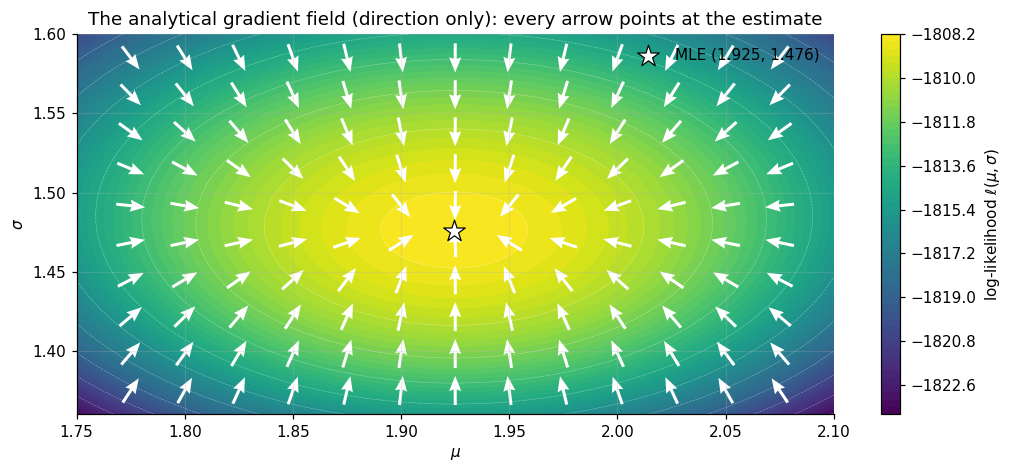

In [16]:
mus = np.linspace(1.75, 2.10, 90)
sigmas = np.linspace(1.36, 1.60, 90)
surface = loglik_2d(Normal, sample, "mu", mus, "sigma", sigmas)

arrow_mu, arrow_sigma = np.meshgrid(np.linspace(1.775, 2.075, 13),
                                    np.linspace(1.375, 1.585, 10))
steps = np.array([
    -normal_gradient(np.array([m, s]))      # minus: downhill on the objective
    for m, s in zip(arrow_mu.ravel(), arrow_sigma.ravel())
])
# Only the direction is drawn: the raw magnitudes span three orders of magnitude
# across this window, which would leave the arrows near the peak invisible.
lengths = np.hypot(steps[:, 0], steps[:, 1])
du = (steps[:, 0] / lengths).reshape(arrow_mu.shape)
dv = (steps[:, 1] / lengths).reshape(arrow_mu.shape)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
filled = ax.contourf(mus, sigmas, surface, levels=60, cmap=CMAP)
ax.contour(mus, sigmas, surface, levels=14, colors="white", linewidths=0.4, alpha=0.4)
fig.colorbar(filled, ax=ax, label=r"log-likelihood $\ell(\mu, \sigma)$")
ax.quiver(arrow_mu, arrow_sigma, du, dv, color="white", pivot="mid",
          width=0.004, scale=26, headwidth=4, headlength=5)
ax.scatter([result.params.mu], [result.params.sigma], color="white", s=220, marker="*",
           zorder=6, edgecolor="black", linewidth=0.8,
           label=f"MLE ({result.params.mu:.3f}, {result.params.sigma:.3f})")
ax.set(xlabel=r"$\mu$", ylabel=r"$\sigma$",
       title="The analytical gradient field (direction only): every arrow points at the estimate")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## 8. Errors versus unsuccessful fits

The line is **recoverability**.

- Data that **no** parameter value could have produced, or a sample that cannot be fitted
  at all, **raise**. `FitDataError` and `InsufficientDataError` are `ValueError` subclasses
  as well as `MLEError`, so existing `except ValueError` code keeps working.
- An optimizer that fails to converge does **not** raise: that is an `MLEResult` with
  `success=False` and a filled `message`.

SciPy mixes the two — `rv_continuous.fit` returns a tuple with no convergence flag, yet
raises `FitError` when the optimizer leaves the admissible region — so a caller there
cannot tell "did not converge" from "wrong data" without reading exception text.

In [17]:
from pysatl_core.estimation import FitDataError, InsufficientDataError, MLEError

def attempt(label, thunk):
    try:
        thunk()
        print(f"{label}\n  -> no error\n")
    except Exception as exc:
        print(f"{label}\n  -> {type(exc).__name__}: {exc}\n")

attempt("gamma fitted to data holding a negative value",
        lambda: Gamma.fit(np.array([-1.0, 1.0, 2.0, 3.0])))
attempt("uniform with lower_bound pinned above min(x)",
        lambda: Uniform.view(lower_bound=3.0).fit(uniform_sample))
attempt("fewer observations than free parameters",
        lambda: Normal.fit(np.array([1.0])))
attempt("a sample holding NaN",
        lambda: Normal.fit(np.array([1.0, np.nan, 2.0])))

gamma fitted to data holding a negative value
  -> FitDataError: 1 of 4 observation(s) lie outside the support ContinuousSupport(left=0.0, right=inf, left_closed=True, right_closed=False) of family 'Gamma', which does not depend on its parameters — for example -1.0. No parameter value can give those points a positive density, so the likelihood is zero everywhere and there is nothing to maximise. Drop them, or fit a family whose support covers the data.

uniform with lower_bound pinned above min(x)
  -> FitDataError: lower_bound is fixed at 3.0, but the sample reaches down to 2.000349384069831. Those observations lie outside every admissible support, so the likelihood is zero for any upper_bound.

fewer observations than free parameters
  -> InsufficientDataError: Family 'Normal' estimates 2 free parameter(s) (mu, sigma), but the sample holds 1 observation(s). At least 2 are required; with fewer, the likelihood has no isolated maximum.

a sample holding NaN
  -> ValueError: Sample must 

**Why does a stray point raise for `Gamma` but not for `ContinuousUniform`?** Because
their supports behave differently. `Gamma`'s support is $[0, \infty)$ whatever its
parameters, so a negative observation is a permanent contradiction. The uniform support
*moves* with its parameters, so a point outside the current interval is only a symptom of
the current iterate — charged a penalty, and the search continues.

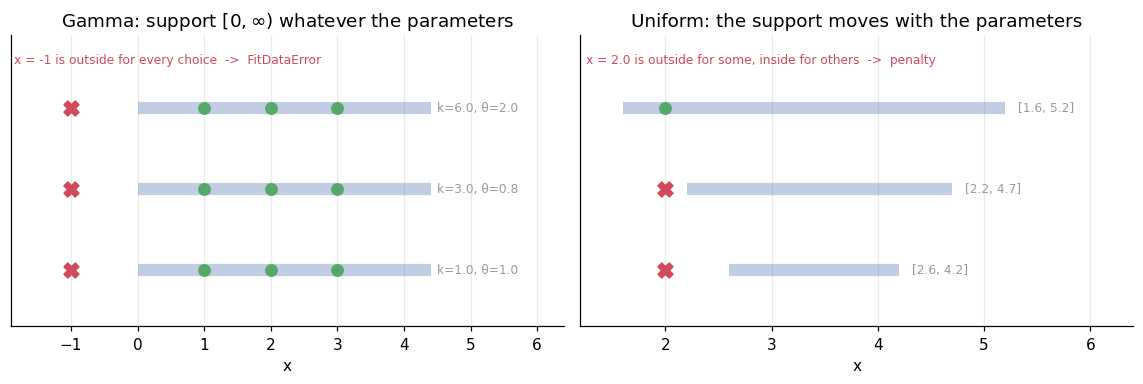

does the support move with the parameters?
  Normal               False
  Gamma                False
  Exponential          False
  ContinuousUniform    True


In [18]:
fig, (ax_fixed, ax_moving) = plt.subplots(1, 2, figsize=(10.5, 3.6))

# Left: the gamma support is [0, inf) for every (k, theta), so three different
# parameter choices draw the very same band.
points = np.array([-1.0, 1.0, 2.0, 3.0])
for row, (k, theta) in enumerate(((1.0, 1.0), (3.0, 0.8), (6.0, 2.0))):
    ax_fixed.hlines(row, 0, 4.4, color=DATA, lw=8, alpha=0.35)
    ax_fixed.text(4.5, row, f"k={k}, θ={theta}", va="center", fontsize=8, color=MUTED)
    inside = points >= 0
    ax_fixed.scatter(points[inside], np.full(inside.sum(), row), color=ALT, s=55, zorder=5)
    ax_fixed.scatter(points[~inside], np.full((~inside).sum(), row), color=BAD, s=95,
                     marker="X", zorder=5)
ax_fixed.set(xlim=(-1.9, 6.4), ylim=(-0.7, 2.9), yticks=[], xlabel="x",
             title=r"Gamma: support $[0,\infty)$ whatever the parameters")
ax_fixed.text(-1.85, 2.55, "x = -1 is outside for every choice  ->  FitDataError",
              fontsize=8, color=BAD)

# Right: the uniform support moves, so the same point changes status.
probe_point = 2.0
for row, (a, b) in enumerate(((2.6, 4.2), (2.2, 4.7), (1.6, 5.2))):
    ax_moving.hlines(row, a, b, color=DATA, lw=8, alpha=0.35)
    ax_moving.text(b + 0.12, row, f"[{a}, {b}]", va="center", fontsize=8, color=MUTED)
    is_inside = a <= probe_point <= b
    ax_moving.scatter([probe_point], [row], color=ALT if is_inside else BAD,
                      s=55 if is_inside else 95, marker="o" if is_inside else "X",
                      zorder=5)
ax_moving.set(xlim=(1.2, 6.4), ylim=(-0.7, 2.9), yticks=[], xlabel="x",
              title=f"Uniform: the support moves with the parameters")
ax_moving.text(1.25, 2.55,
               f"x = {probe_point} is outside for some, inside for others  ->  penalty",
               fontsize=8, color=BAD)

fig.tight_layout()
plt.show()

probe_sample = np.abs(rng.normal(2.0, 1.0, 100)) + 0.5
print("does the support move with the parameters?")
for family in (Normal, Gamma, Exponential, Uniform):
    print(f"  {family.name:20s} {support_depends_on_params(family, probe_sample)}")

Non-convergence, by contrast, is **reported** rather than raised. Starving the optimizer
of iterations gives a usable object that says plainly it did not finish:

In [19]:
starved = Gamma.fit(gamma_sample, optimizer="L-BFGS-B", options={"maxiter": 1})

summarize(starved, "Gamma.fit(..., options={'maxiter': 1})  —  deliberately starved")
print()
print(f"k after 1 iteration: {starved.params.k:.4f}   "
      f"after the full run: {gamma_result.params.k:.4f}")
print("The caller gets a result and a reason, not an exception to parse.")

Gamma.fit(..., options={'maxiter': 1})  —  deliberately starved
---------------------------------------------------------------
  k                      2.451001
  theta                  1.701016
  route            numeric via L-BFGS-B
  converged                 False
  log-likelihood       -4487.2209   (higher = better fit)
  free parameters               2   (estimated, not fixed)
  observations               2000
  AIC                     8978.44   (lower = better, penalises parameters)
  BIC                     8989.64   (lower = better, penalises harder)
  optimizer work                1   iterations, 3 objective evaluations
  message          STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

k after 1 iteration: 2.4510   after the full run: 2.4702
The caller gets a result and a reason, not an exception to parse.


## 9. Parameter bounds

Bounds handed to the optimizer are declared next to the family, in `param_bounds`, and are
a **separate mechanism** from the `@constraint` predicates. Neither can do the other's job:
a predicate is a black box that validates a point but cannot be turned into a search
region, and a box of per-parameter bounds cannot express a relation between two parameters.

So `sigma > 0` is written twice — once as a constraint, once as a bound. That duplication
is deliberate and held together by tests.

In [20]:
for family in (Normal, Gamma, Exponential):
    names = list(family.base.__dataclass_fields__)
    bounds = resolve_bounds(family)
    print(f"{family.name}")
    for name, (low, high) in zip(names, bounds):
        kind = "declared" if family.param_bounds.get(name) else "unbounded (no entry)"
        print(f"  {name:<10} [{low:>10.3g}, {high:>8.3g}]   {kind}")
    print()

print("An open bound reaches the optimizer as a closed box nudged off the edge by one ULP:")
print(f"  sigma > 0  ->  lower bound {resolve_bounds(Normal)[1][0]!r}")
print("  and the objective returning inf inside that gap is what keeps the search out.")
print()
print("A view keeps only the free parameters, in declaration order:")
view = Gamma.view(k=2.0)
print(f"  Gamma.view(k=2)  {list(view.base.__dataclass_fields__)} -> {resolve_bounds(view)}")

Normal
  mu         [      -inf,      inf]   unbounded (no entry)
  sigma      [ 4.94e-324,      inf]   declared

Gamma
  k          [ 4.94e-324,      inf]   declared
  theta      [ 4.94e-324,      inf]   declared

Exponential
  lambda_    [ 4.94e-324,      inf]   declared

An open bound reaches the optimizer as a closed box nudged off the edge by one ULP:
  sigma > 0  ->  lower bound 5e-324
  and the objective returning inf inside that gap is what keeps the search out.

A view keeps only the free parameters, in declaration order:
  Gamma.view(k=2)  ['theta'] -> [(5e-324, inf)]


**Why does `ContinuousUniform` declare no bounds at all?** Its only restriction is
`lower_bound < upper_bound` — a *relation*, not a range. The admissible set is a half-plane,
and no rectangle equals it: every box either lets in inadmissible points or excludes valid
ones.

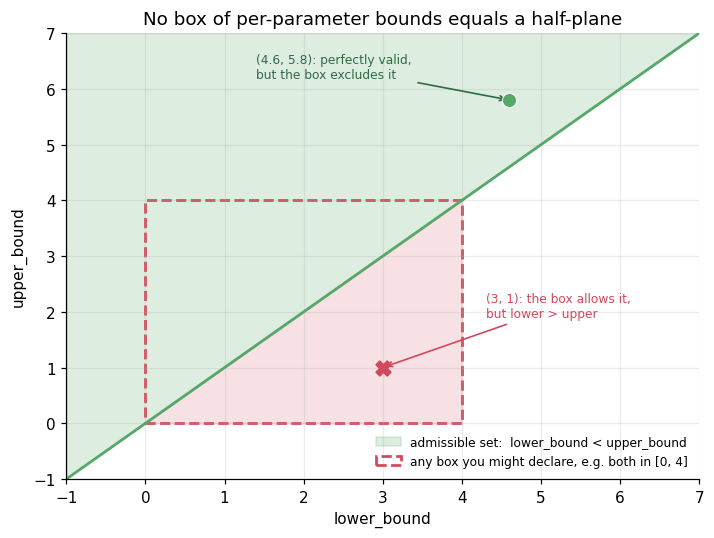

resolve_bounds(ContinuousUniform) = None



In [21]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))

edge = np.linspace(-1, 7, 200)
ax.fill_between(edge, edge, 7, color=ALT, alpha=0.20,
                label="admissible set:  lower_bound < upper_bound")
ax.plot(edge, edge, color=ALT, lw=1.8)

# One candidate box, [0, 4] x [0, 4]. It fails in both directions at once.
box = plt.Rectangle((0, 0), 4, 4, fill=False, ls="--", lw=1.8, color=BAD,
                    label="any box you might declare, e.g. both in [0, 4]")
ax.add_patch(box)
ax.fill_between([0, 4], [0, 0], [0, 4], color=BAD, alpha=0.16)
ax.scatter([3.0], [1.0], color=BAD, s=95, marker="X", zorder=5)
ax.annotate("(3, 1): the box allows it,\nbut lower > upper",
            xy=(3.0, 1.0), xytext=(4.3, 1.9), fontsize=8, color=BAD,
            arrowprops=dict(arrowstyle="->", color=BAD, lw=1.1))

ax.scatter([4.6], [5.8], color=ALT, s=85, zorder=5, edgecolor="white", linewidth=0.6)
ax.annotate("(4.6, 5.8): perfectly valid,\nbut the box excludes it",
            xy=(4.6, 5.8), xytext=(1.4, 6.2), fontsize=8, color="#2F6B45",
            arrowprops=dict(arrowstyle="->", color="#2F6B45", lw=1.1))

ax.set(xlim=(-1, 7), ylim=(-1, 7), xlabel="lower_bound", ylabel="upper_bound",
       title="No box of per-parameter bounds equals a half-plane")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    print(f"resolve_bounds(ContinuousUniform) = {resolve_bounds(Uniform)}")
print(f"\nwarning: {caught[0].message}")

## 10. Summary

| | Normal | Exponential | ContinuousUniform | Gamma |
|---|---|---|---|---|
| closed form | yes | yes | yes | no *(TODO)* |
| `param_bounds` | `sigma > 0` | `lambda_ > 0` | none (coupled) | `k, theta > 0` |
| support moves with parameters | no | no | yes | no |
| default route | closed form | closed form | closed form | L-BFGS-B + `score` |

What the API guarantees:

- `fit` lives on the **family**, so views and user-defined families work without subclassing.
- The search always runs in the **base parametrization**; maximum likelihood is invariant to
  reparametrisation in theory, but numerically the variants have different conditioning, and
  the estimate should not depend on the coordinates it was asked for.
- An explicitly requested `optimizer` is **honoured**, with a warning when a closed form was
  available.
- Failure to converge is a **result**, not an exception.

All four families, fitted and drawn over their own data:

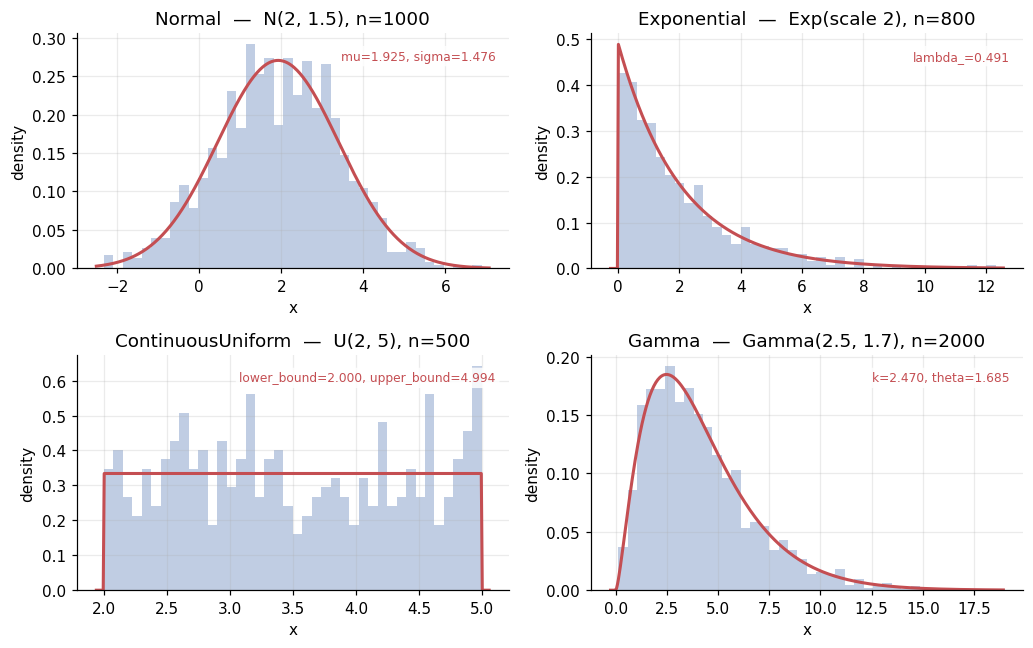

family              route         optimizer         log-lik         AIC
Normal              closed_form   None             -1808.23     3620.47
Exponential         closed_form   None             -1368.62     2739.24
ContinuousUniform   closed_form   None              -548.22     1100.43
Gamma               numeric       L-BFGS-B         -4487.18     8978.36


In [22]:
exponential_sample = rng.exponential(2.0, 800)
datasets = [
    (Normal, sample, "Normal", "N(2, 1.5), n=1000"),
    (Exponential, exponential_sample, "Exponential", "Exp(scale 2), n=800"),
    (Uniform, uniform_sample, "ContinuousUniform", "U(2, 5), n=500"),
    (Gamma, gamma_sample, "Gamma", "Gamma(2.5, 1.7), n=2000"),
]

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.0))
rows = []

for ax, (family, data, name, subtitle) in zip(axes.ravel(), datasets):
    res = family.fit(data)
    span = data.max() - data.min()
    grid = np.linspace(data.min() - 0.02 * span, data.max() + 0.02 * span, 400)
    ax.hist(data, bins=40, density=True, color=DATA, alpha=0.35)
    ax.plot(grid, res.distribution.calculate_characteristic("pdf", grid), color=FIT, lw=2)
    estimates = ", ".join(f"{k}={v:.3f}" for k, v in res.params.parameters.items())
    ax.set(title=f"{name}  —  {subtitle}", xlabel="x", ylabel="density")
    ax.text(0.97, 0.93, estimates, transform=ax.transAxes, fontsize=8, va="top",
            ha="right", color=FIT,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, lw=0))
    rows.append((name, res))

fig.tight_layout()
plt.show()

print(f"{'family':<20}{'route':<14}{'optimizer':<12}{'log-lik':>13}{'AIC':>12}")
for name, res in rows:
    print(f"{name:<20}{res.method:<14}{str(res.optimizer):<12}"
          f"{res.log_likelihood:>13.2f}{res.aic:>12.2f}")